In [19]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
load_list = range(1,11)
seed_list = [1,2,3,4,5]
oversub_list = [0.33,0.67,1.33,1.67]
scheme_list = ["dringsu2","leafspine"]

In [17]:
import os

sumfile = "fct_summary.txt"
datadict = dict()
with open(sumfile,'a') as fw:
    for scheme in scheme_list:
        for oversub in oversub_list:
            for load in load_list:
                for seed in seed_list:
                    outfile = f"outfiles/{scheme}_oversub{oversub}_load{load}_seed{seed}.out"
                    if os.path.exists(outfile):
                        durationlist = list()
                        sizelist = list()
                        startlist = list()
                        with open(outfile,'r') as fr:
                            lines = fr.readlines()
                            for line in lines:
                                tokens = line.split()
                                if tokens[0] == "FCT":
                                    durationlist.append(float(tokens[2]))
                                    sizelist.append(int(tokens[1]))
                                    startlist.append(float(tokens[3]))
                        durationlist.sort()
                        datadict[outfile] = [durationlist,sizelist,startlist]
                        
                        fw.write(f"{outfile}\t{sum(durationlist)/len(durationlist)}\t{durationlist[int(len(durationlist)*0.5)]}\t{durationlist[int(len(durationlist)*0.99)]}\t{durationlist[int(len(durationlist)*0.9999)]}\n")

        # intentional -- repeatedly save current progress
        with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_bottleneck_oversub.pickle', 'wb') as handle:
            pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

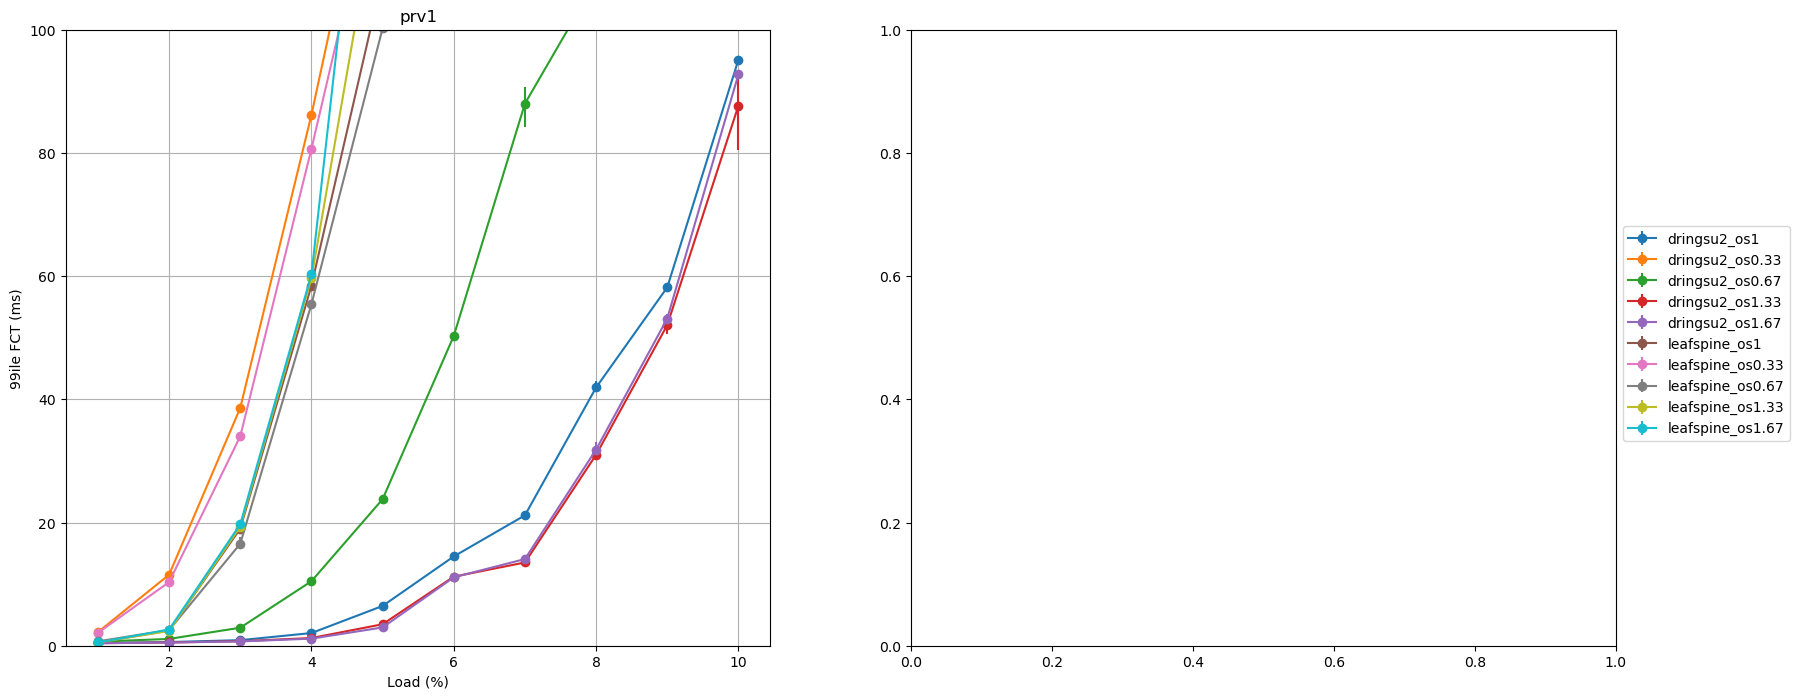

In [20]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        plotdatadict[outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        plotevalmaindatadict[outfile] = p99


markerlist = ['o','x']
nr = 1
nc = 2
fig, axs =plt.subplots(nr, nc, figsize=(nc*10, nr*8))
for ic,cm in enumerate(["prv1"]):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        for load in load_list:
            fct_list_allseeds = list()
            for seed in seed_list:
                outfile = f"prv1/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotevalmaindatadict[outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        if ic==0:
            axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], label=f"{scheme}_os1")
        else:
            axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10])
            

        for oversub in oversub_list:
            fct_list = list()
            for load in load_list:
                fct_list_allseeds = list()
                for seed in seed_list:
                    outfile = f"outfiles/{scheme}_oversub{oversub}_load{load}_seed{seed}.out"
                    p99 = plotdatadict[outfile]
                    fct_list_allseeds.append(p99)
                fct_list.append(fct_list_allseeds)
            if ic==0:
                axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10], label=f"{scheme}_os{oversub}")
            else:
                axs[ic].errorbar(load_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=markerlist[isc//10])
                    
    axs[ic].set_xlabel("Load (%)")
    axs[ic].set_ylabel("99ile FCT (ms)")
    axs[ic].set_ylim(0,100)
    axs[ic].set_title(cm)
    axs[ic].grid(True)
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))